In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ============================================================
# 1. SETTINGS
# ============================================================

data_folder = Path(r"C:/Users/sh1345/code/myproject/Project 1/data/weather data")

airport_file = data_folder / "airport_weather_clean_2007_to_2023_02_28.csv"
openmeteo_file = data_folder / "open_meteo_historical_forecast_Rotorua_2017_2026.csv"
observed_s_file = data_folder / "gap filled data.xlsx"

bias_summary_file = data_folder / "bias_summary_airport_vs_openmeteo_3hourly_overlap.csv"
overlap_comparison_file = data_folder / "airport_openmeteo_3hourly_overlap_comparison.csv"

openmeteo_corrected_hourly_file = data_folder / "openmeteo_bias_corrected_hourly_2017_2026.csv"
openmeteo_corrected_3hourly_file = data_folder / "openmeteo_bias_corrected_3hourly_model_grid_2017_2026.csv"
openmeteo_corrected_forecast_file = data_folder / "openmeteo_bias_corrected_3hourly_forecast_period_2023_onward.csv"

datetime_col = "datetime_NZ"

# Bias correction period
bias_start = pd.Timestamp("2017-01-01 00:00:00")
bias_end = pd.Timestamp("2023-02-28 23:59:59")

# Forecast/test period
forecast_start = pd.Timestamp("2023-03-01 00:00:00")
forecast_end = None

In [ ]:

#This observed data is only used to define the 3-hourly model grid

# ============================================================
# 2. READ OBSERVED S DATA TO GET THE 3-HOURLY MODEL GRID
# ============================================================

obs = pd.read_excel(observed_s_file)

obs["datetime"] = pd.to_datetime(obs["datetime"], errors="coerce")
obs = obs.dropna(subset=["datetime"]).copy()
obs = obs.sort_values("datetime").reset_index(drop=True)

# Keep only unique S/model timestamps
model_grid = (
    obs[["datetime"]]
    .drop_duplicates()
    .rename(columns={"datetime": datetime_col})
    .sort_values(datetime_col)
    .reset_index(drop=True)
)

print("=" * 80)
print("OBSERVED S / MODEL GRID")
print("=" * 80)
print("Shape:", model_grid.shape)
print("Start:", model_grid[datetime_col].min())
print("End:  ", model_grid[datetime_col].max())

time_diffs = model_grid[datetime_col].diff().dropna()
print("Most common time step:", time_diffs.mode().iloc[0])
print("Number of gaps > 3 hours:", (time_diffs > pd.Timedelta(hours=3)).sum())

OBSERVED S / MODEL GRID
Shape: (54536, 1)
Start: 2007-07-13 12:00:00
End:   2026-03-12 09:00:00
Most common time step: 0 days 03:00:00
Number of gaps > 3 hours: 0


In [3]:
# ============================================================
# 3. READ CLEAN AIRPORT WEATHER DATA
# ============================================================

airport = pd.read_csv(airport_file)

airport[datetime_col] = pd.to_datetime(
    airport[datetime_col],
    errors="coerce"
)

airport = airport.dropna(subset=[datetime_col]).copy()
airport = airport.sort_values(datetime_col).reset_index(drop=True)

print("\n" + "=" * 80)
print("AIRPORT WEATHER")
print("=" * 80)
print("Shape:", airport.shape)
print("Start:", airport[datetime_col].min())
print("End:  ", airport[datetime_col].max())
print("Missing values:")
print(airport.isna().sum())


AIRPORT WEATHER
Shape: (141659, 10)
Start: 2007-01-01 13:00:00
End:   2023-02-28 23:00:00
Missing values:
datetime_NZ                   0
air_temperature_deg_c         0
relative_humidity_percent     0
wind_speed_m_s                0
wind_direction_sin            0
wind_direction_cos            0
gust_speed_m_s                0
rainfall_mm                   0
radiation_w_m2                0
station_level_pressure_hpa    0
dtype: int64


In [4]:

# ============================================================
# 4. READ OPEN-METEO HISTORICAL FORECAST DATA
# ============================================================

om = pd.read_csv(openmeteo_file)
om.columns = om.columns.str.strip()

# Your Open-Meteo file uses this local/NZ-style datetime column
om_datetime_col = "datetime (UTC+13)"

om[datetime_col] = pd.to_datetime(
    om[om_datetime_col],
    errors="coerce",
    dayfirst=True
)

om = om.dropna(subset=[datetime_col]).copy()
om = om.sort_values(datetime_col).reset_index(drop=True)

print("\n" + "=" * 80)
print("OPEN-METEO RAW")
print("=" * 80)
print("Shape:", om.shape)
print("Start:", om[datetime_col].min())
print("End:  ", om[datetime_col].max())
print("Columns:")
for col in om.columns:
    print("-", col)


OPEN-METEO RAW
Shape: (82656, 11)
Start: 2017-01-01 13:00:00
End:   2026-06-07 11:00:00
Columns:
- datetime (UTC+13)
- temperature_2m_C
- relative_humidity_2m_percent
- precipitation_mm
- rain_mm
- surface_pressure_hPa
- wind_speed_10m_ms
- wind_gusts_10m_ms
- wind_direction_10m_deg
- shortwave_radiation_W_m2
- datetime_NZ


In [5]:

# ============================================================
# 5. RENAME OPEN-METEO COLUMNS TO MATCH AIRPORT NAMES
# ============================================================

om = om.rename(columns={
    "temperature_2m_C": "air_temperature_deg_c",
    "relative_humidity_2m_percent": "relative_humidity_percent",
    "wind_speed_10m_ms": "wind_speed_m_s",
    "wind_gusts_10m_ms": "gust_speed_m_s",
    "rain_mm": "rainfall_mm",
    "shortwave_radiation_W_m2": "radiation_w_m2",
    "surface_pressure_hPa": "station_level_pressure_hpa",
    "wind_direction_10m_deg": "wind_direction_deg",
})

# Convert Open-Meteo wind direction degrees to sin/cos
if "wind_direction_deg" in om.columns:
    om.loc[
        (om["wind_direction_deg"] < 0) |
        (om["wind_direction_deg"] > 360),
        "wind_direction_deg"
    ] = np.nan

    radians = np.deg2rad(om["wind_direction_deg"])

    om["wind_direction_sin"] = np.sin(radians)
    om["wind_direction_cos"] = np.cos(radians)

    # Keep degree column for circular bias correction later
    # but model input will use sin/cos

In [6]:
# ============================================================
# 6. VARIABLES TO COMPARE AND CORRECT
# ============================================================

continuous_vars = [
    "air_temperature_deg_c",
    "relative_humidity_percent",
    "wind_speed_m_s",
    "gust_speed_m_s",
    "radiation_w_m2",
    "station_level_pressure_hpa",
]

rain_var = "rainfall_mm"

direction_vars = [
    "wind_direction_sin",
    "wind_direction_cos",
]

candidate_vars = continuous_vars + [rain_var] + direction_vars

variables = [
    col for col in candidate_vars
    if col in airport.columns and col in om.columns
]

print("\n" + "=" * 80)
print("COMPARABLE MODEL WEATHER VARIABLES")
print("=" * 80)
for col in variables:
    print("-", col)


COMPARABLE MODEL WEATHER VARIABLES
- air_temperature_deg_c
- relative_humidity_percent
- wind_speed_m_s
- gust_speed_m_s
- radiation_w_m2
- station_level_pressure_hpa
- rainfall_mm
- wind_direction_sin
- wind_direction_cos


In [7]:
# ============================================================
# 7. PREPARE AIRPORT AND OPEN-METEO ON THE S 3-HOURLY GRID
# ============================================================

def prepare_unique(df, datetime_col, cols):
    df = df[[datetime_col] + cols].copy()

    df[datetime_col] = pd.to_datetime(df[datetime_col], errors="coerce")
    df = df.dropna(subset=[datetime_col]).copy()

    for col in cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    duplicate_count = df[datetime_col].duplicated().sum()

    if duplicate_count > 0:
        print(f"Averaging {duplicate_count} duplicate timestamps.")
        df = df.groupby(datetime_col, as_index=False).mean(numeric_only=True)

    df = df.sort_values(datetime_col).reset_index(drop=True)
    return df


airport_small = prepare_unique(airport, datetime_col, variables)
om_small = prepare_unique(om, datetime_col, variables)

# Align both weather datasets to the actual S/model timestamps
airport_3h = pd.merge(
    model_grid,
    airport_small,
    on=datetime_col,
    how="left"
)

om_3h = pd.merge(
    model_grid,
    om_small,
    on=datetime_col,
    how="left"
)

print("\n" + "=" * 80)
print("AIRPORT ON 3-HOURLY S GRID")
print("=" * 80)
print("Shape:", airport_3h.shape)
print("Start:", airport_3h[datetime_col].min())
print("End:  ", airport_3h[datetime_col].max())
print("Missing values:")
print(airport_3h.isna().sum())

print("\n" + "=" * 80)
print("OPEN-METEO ON 3-HOURLY S GRID")
print("=" * 80)
print("Shape:", om_3h.shape)
print("Start:", om_3h[datetime_col].min())
print("End:  ", om_3h[datetime_col].max())
print("Missing values:")
print(om_3h.isna().sum())

Averaging 10 duplicate timestamps.

AIRPORT ON 3-HOURLY S GRID
Shape: (54536, 10)
Start: 2007-07-13 12:00:00
End:   2026-03-12 09:00:00
Missing values:
datetime_NZ                      0
air_temperature_deg_c         8860
relative_humidity_percent     8860
wind_speed_m_s                8860
gust_speed_m_s                8860
radiation_w_m2                8860
station_level_pressure_hpa    8860
rainfall_mm                   8860
wind_direction_sin            8860
wind_direction_cos            8860
dtype: int64

OPEN-METEO ON 3-HOURLY S GRID
Shape: (54536, 10)
Start: 2007-07-13 12:00:00
End:   2026-03-12 09:00:00
Missing values:
datetime_NZ                       0
air_temperature_deg_c         27681
relative_humidity_percent     27681
wind_speed_m_s                27681
gust_speed_m_s                27681
radiation_w_m2                27681
station_level_pressure_hpa    27681
rainfall_mm                   27681
wind_direction_sin            27681
wind_direction_cos            27681
dtype

In [8]:
# ============================================================
# CHECK WEATHER AVAILABILITY IN BIAS OVERLAP ONLY
# ============================================================

bias_start = pd.Timestamp("2017-01-01 00:00:00")
bias_end = pd.Timestamp("2023-02-28 23:59:59")

airport_overlap_check = airport_3h[
    (airport_3h[datetime_col] >= bias_start) &
    (airport_3h[datetime_col] <= bias_end)
].copy()

om_overlap_check = om_3h[
    (om_3h[datetime_col] >= bias_start) &
    (om_3h[datetime_col] <= bias_end)
].copy()

print("\n" + "=" * 80)
print("AIRPORT WEATHER IN BIAS OVERLAP ONLY")
print("=" * 80)
print("Shape:", airport_overlap_check.shape)
print("Start:", airport_overlap_check[datetime_col].min())
print("End:  ", airport_overlap_check[datetime_col].max())
print("Missing values:")
print(airport_overlap_check.isna().sum())

print("\n" + "=" * 80)
print("OPEN-METEO WEATHER IN BIAS OVERLAP ONLY")
print("=" * 80)
print("Shape:", om_overlap_check.shape)
print("Start:", om_overlap_check[datetime_col].min())
print("End:  ", om_overlap_check[datetime_col].max())
print("Missing values:")
print(om_overlap_check.isna().sum())


AIRPORT WEATHER IN BIAS OVERLAP ONLY
Shape: (18000, 10)
Start: 2017-01-01 00:00:00
End:   2023-02-28 21:00:00
Missing values:
datetime_NZ                   0
air_temperature_deg_c         0
relative_humidity_percent     0
wind_speed_m_s                0
gust_speed_m_s                0
radiation_w_m2                0
station_level_pressure_hpa    0
rainfall_mm                   0
wind_direction_sin            0
wind_direction_cos            0
dtype: int64

OPEN-METEO WEATHER IN BIAS OVERLAP ONLY
Shape: (18000, 10)
Start: 2017-01-01 00:00:00
End:   2023-02-28 21:00:00
Missing values:
datetime_NZ                   0
air_temperature_deg_c         5
relative_humidity_percent     5
wind_speed_m_s                5
gust_speed_m_s                5
radiation_w_m2                5
station_level_pressure_hpa    5
rainfall_mm                   5
wind_direction_sin            5
wind_direction_cos            5
dtype: int64


In [9]:
# ============================================================
# 8. CREATE OVERLAP FOR BIAS CALCULATION
# ============================================================

comparison = pd.merge(
    airport_3h,
    om_3h,
    on=datetime_col,
    how="inner",
    suffixes=("_airport", "_om")
)

overlap = comparison[
    (comparison[datetime_col] >= bias_start) &
    (comparison[datetime_col] <= bias_end)
].copy()

print("\n" + "=" * 80)
print("BIAS-CORRECTION OVERLAP ON 3-HOURLY S GRID")
print("=" * 80)
print("Shape:", overlap.shape)
print("Start:", overlap[datetime_col].min())
print("End:  ", overlap[datetime_col].max())

if overlap.empty:
    raise ValueError("No overlap found. Check datetime alignment.")


BIAS-CORRECTION OVERLAP ON 3-HOURLY S GRID
Shape: (18000, 19)
Start: 2017-01-01 00:00:00
End:   2023-02-28 21:00:00


In [10]:
# ============================================================
# 9. GLOBAL BIAS SUMMARY
# ============================================================

bias_rows = []

for var in variables:
    airport_col = f"{var}_airport"
    om_col = f"{var}_om"

    valid = overlap[[datetime_col, airport_col, om_col]].dropna()

    if valid.empty:
        print(f"Skipping {var}: no valid overlap.")
        continue

    obs_airport = valid[airport_col]
    pred_om = valid[om_col]
    diff = pred_om - obs_airport

    mae = mean_absolute_error(obs_airport, pred_om)
    rmse = np.sqrt(mean_squared_error(obs_airport, pred_om))

    try:
        r2 = r2_score(obs_airport, pred_om)
    except Exception:
        r2 = np.nan

    pbias = (
        100 * (pred_om.sum() - obs_airport.sum()) / obs_airport.sum()
        if obs_airport.sum() != 0
        else np.nan
    )

    bias_rows.append({
        "variable": var,
        "n_overlap": len(valid),
        "airport_mean": obs_airport.mean(),
        "openmeteo_mean": pred_om.mean(),
        "mean_bias_OM_minus_airport": diff.mean(),
        "median_bias_OM_minus_airport": diff.median(),
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "PBIAS_percent": pbias,
        "airport_min": obs_airport.min(),
        "airport_max": obs_airport.max(),
        "openmeteo_min": pred_om.min(),
        "openmeteo_max": pred_om.max(),
    })

bias_summary = pd.DataFrame(bias_rows)

print("\n" + "=" * 80)
print("GLOBAL BIAS SUMMARY ON 3-HOURLY GRID")
print("=" * 80)
print(bias_summary.to_string(index=False))

bias_summary.to_csv(bias_summary_file, index=False)
overlap.to_csv(overlap_comparison_file, index=False)


GLOBAL BIAS SUMMARY ON 3-HOURLY GRID
                  variable  n_overlap  airport_mean  openmeteo_mean  mean_bias_OM_minus_airport  median_bias_OM_minus_airport       MAE      RMSE        R2  PBIAS_percent  airport_min  airport_max  openmeteo_min  openmeteo_max
     air_temperature_deg_c      17995     13.311274       13.236378                   -0.074896                     -0.265500  1.040874  1.356418  0.930402      -0.562650        -2.80      30.2000      -0.915500      30.234500
 relative_humidity_percent      17995     82.232135       83.303941                    1.071806                      1.682996  5.994887  7.810530  0.661619       1.303390        24.70     100.0000      23.031612     100.000000
            wind_speed_m_s      17995      3.678076        3.274885                   -0.403191                     -0.315559  1.147236  1.481677  0.563096     -10.962013         0.06      16.4700       0.100000      12.976903
            gust_speed_m_s      17995      6.372977   

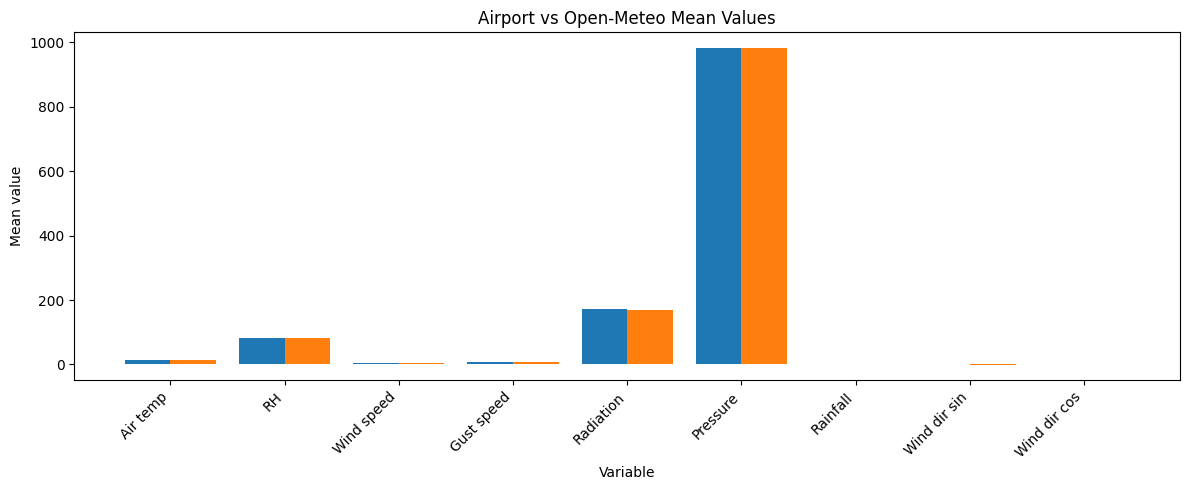

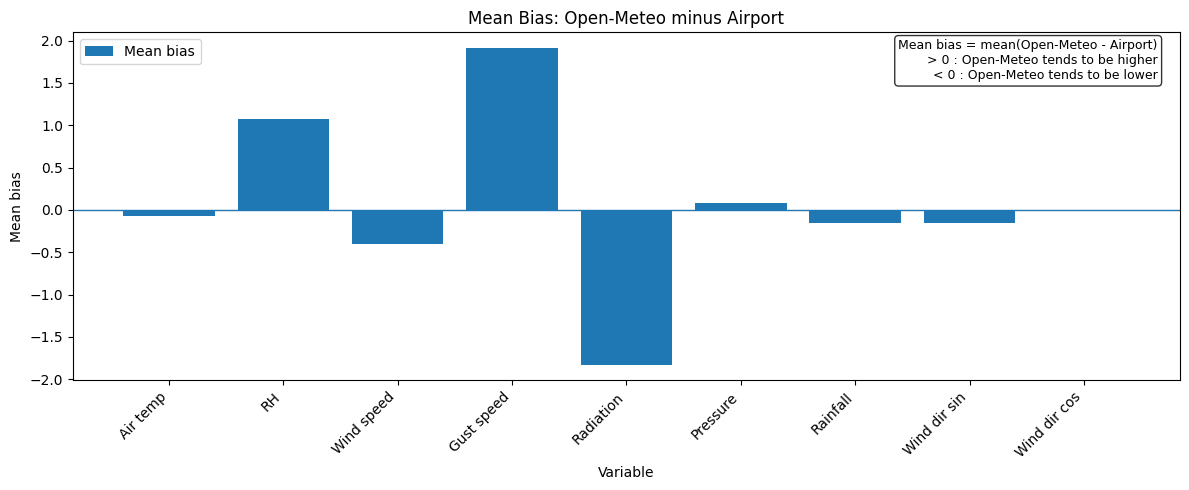

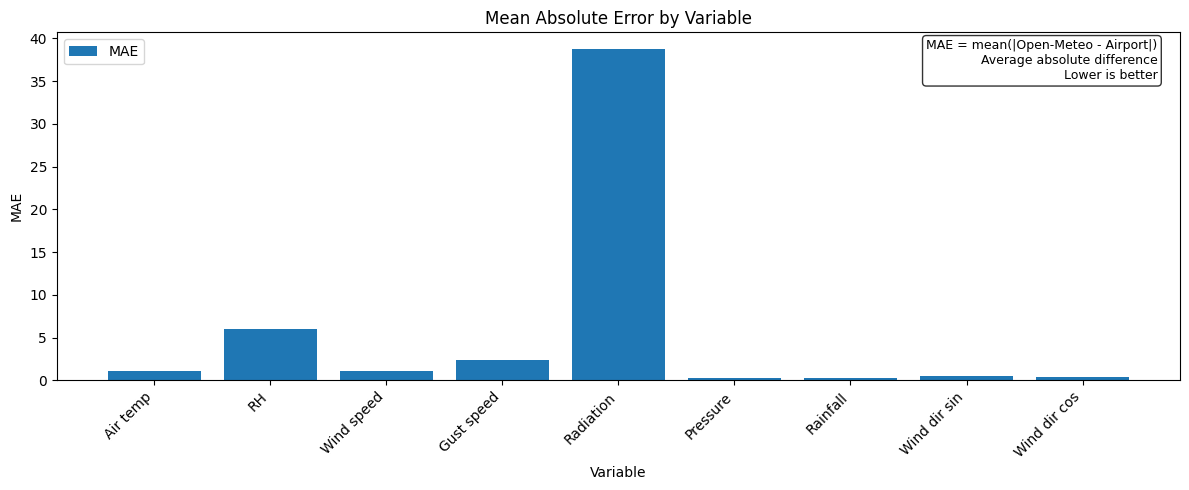

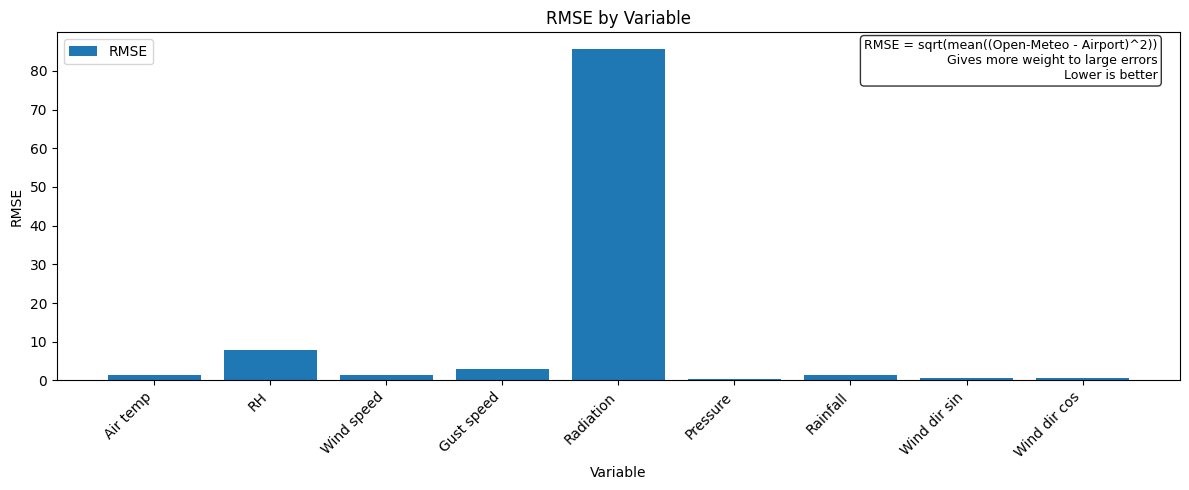

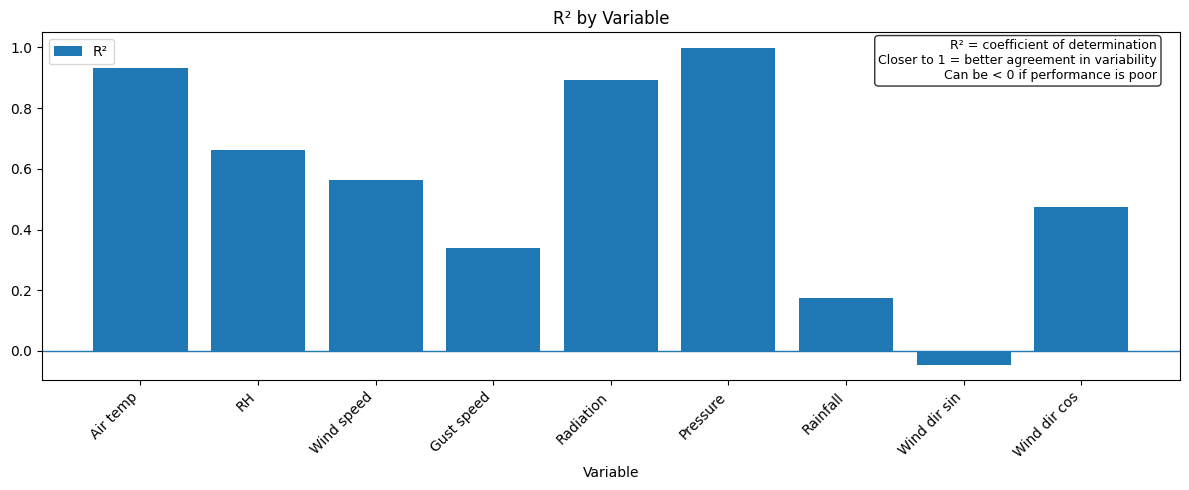

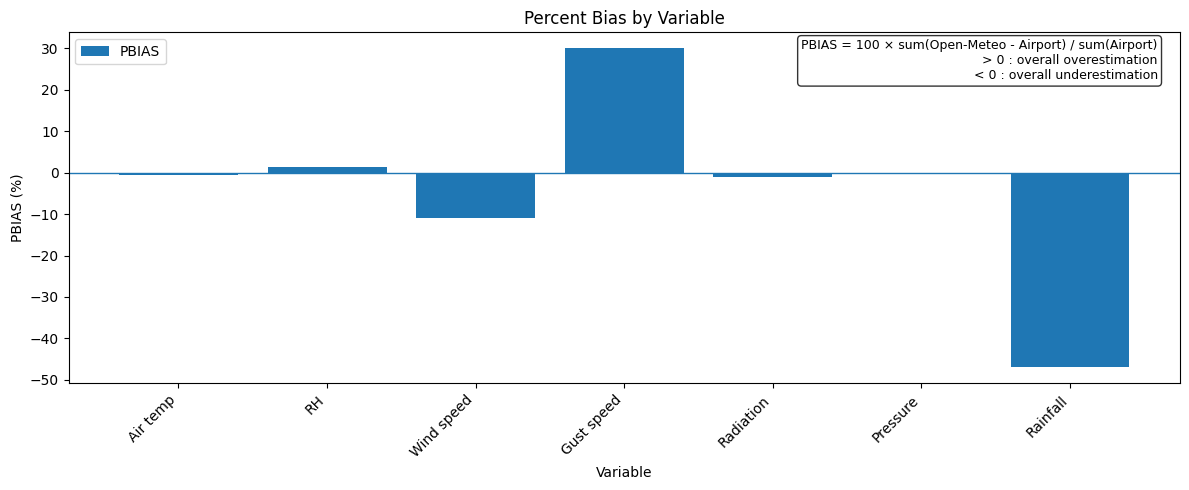

Plots saved to: C:\Users\sh1345\code\myproject\Project 1\data\weather data\bias_metric_plots


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# 1. SETTINGS
# ============================================================

data_folder = Path(r"C:/Users/sh1345/code/myproject/Project 1/data/weather data")
bias_summary_file = data_folder / "bias_summary_airport_vs_openmeteo_3hourly_overlap.csv"

plot_folder = data_folder / "bias_metric_plots"
plot_folder.mkdir(exist_ok=True)

# ============================================================
# 2. READ DATA
# ============================================================

df = pd.read_csv(bias_summary_file)

label_map = {
    "air_temperature_deg_c": "Air temp",
    "relative_humidity_percent": "RH",
    "wind_speed_m_s": "Wind speed",
    "gust_speed_m_s": "Gust speed",
    "radiation_w_m2": "Radiation",
    "station_level_pressure_hpa": "Pressure",
    "rainfall_mm": "Rainfall",
    "wind_direction_sin": "Wind dir sin",
    "wind_direction_cos": "Wind dir cos",
}

df["label"] = df["variable"].map(label_map).fillna(df["variable"])

# ============================================================
# HELPER FUNCTION FOR METRIC EXPLANATION BOX
# ============================================================

def add_metric_box(text):
    plt.gca().text(
        0.98, 0.98, text,
        transform=plt.gca().transAxes,
        fontsize=9,
        verticalalignment="top",
        horizontalalignment="right",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
    )

# ============================================================
# 3. AIRPORT MEAN VS OPEN-METEO MEAN
# ============================================================

x = range(len(df))
width = 0.4

plt.figure(figsize=(12, 5))
plt.bar([i - width/2 for i in x], df["airport_mean"], width=width, label="Airport mean")
plt.bar([i + width/2 for i in x], df["openmeteo_mean"], width=width, label="Open-Meteo mean")
plt.xticks(list(x), df["label"], rotation=45, ha="right")
plt.title("Airport vs Open-Meteo Mean Values")
plt.xlabel("Variable")
# plt.ylabel("Mean value")
# plt.legend()

# add_metric_box(
#     "Airport mean = mean(observed airport values)\n"
#     "Open-Meteo mean = mean(Open-Meteo values)"
# )

plt.tight_layout()
plt.savefig(plot_folder / "01_airport_vs_openmeteo_means.png", dpi=300)
plt.show()

# ============================================================
# 4. MEAN BIAS
# ============================================================

plt.figure(figsize=(12, 5))
plt.bar(df["label"], df["mean_bias_OM_minus_airport"], label="Mean bias")
plt.axhline(0, linewidth=1)
plt.xticks(rotation=45, ha="right")
plt.title("Mean Bias: Open-Meteo minus Airport")
plt.xlabel("Variable")
# plt.ylabel("Mean bias")
plt.legend()

add_metric_box(
    "Mean bias = mean(Open-Meteo - Airport)\n"
    "> 0 : Open-Meteo tends to be higher\n"
    "< 0 : Open-Meteo tends to be lower"
)

plt.tight_layout()
plt.savefig(plot_folder / "02_mean_bias.png", dpi=300)
plt.show()

# ============================================================
# 5. MAE
# ============================================================

plt.figure(figsize=(12, 5))
plt.bar(df["label"], df["MAE"], label="MAE")
plt.xticks(rotation=45, ha="right")
plt.title("Mean Absolute Error by Variable")
plt.xlabel("Variable")
# plt.ylabel("MAE")
plt.legend()

add_metric_box(
    "MAE = mean(|Open-Meteo - Airport|)\n"
    "Average absolute difference\n"
    "Lower is better"
)

plt.tight_layout()
plt.savefig(plot_folder / "03_mae.png", dpi=300)
plt.show()

# ============================================================
# 6. RMSE
# ============================================================

plt.figure(figsize=(12, 5))
plt.bar(df["label"], df["RMSE"], label="RMSE")
plt.xticks(rotation=45, ha="right")
plt.title("RMSE by Variable")
plt.xlabel("Variable")
# plt.ylabel("RMSE")
plt.legend()

add_metric_box(
    "RMSE = sqrt(mean((Open-Meteo - Airport)^2))\n"
    "Gives more weight to large errors\n"
    "Lower is better"
)

plt.tight_layout()
plt.savefig(plot_folder / "04_rmse.png", dpi=300)
plt.show()

# ============================================================
# 7. R²
# ============================================================

plt.figure(figsize=(12, 5))
plt.bar(df["label"], df["R2"], label="R²")
plt.axhline(0, linewidth=1)
plt.xticks(rotation=45, ha="right")
plt.title("R² by Variable")
plt.xlabel("Variable")
# plt.ylabel("R²")
plt.legend()

add_metric_box(
    "R² = coefficient of determination\n"
    "Closer to 1 = better agreement in variability\n"
    "Can be < 0 if performance is poor"
)

plt.tight_layout()
plt.savefig(plot_folder / "05_r2.png", dpi=300)
plt.show()

# ============================================================
# 8. PBIAS
# ============================================================

df_no_wd = df[
    ~df["variable"].isin(["wind_direction_sin", "wind_direction_cos"])
].copy()

plt.figure(figsize=(12, 5))
plt.bar(df_no_wd["label"], df_no_wd["PBIAS_percent"], label="PBIAS")
plt.axhline(0, linewidth=1)
plt.xticks(rotation=45, ha="right")
plt.title("Percent Bias by Variable")
plt.xlabel("Variable")
plt.ylabel("PBIAS (%)")
plt.legend()

add_metric_box(
    "PBIAS = 100 × sum(Open-Meteo - Airport) / sum(Airport)\n"
    "> 0 : overall overestimation\n"
    "< 0 : overall underestimation"
)

plt.tight_layout()
plt.savefig(plot_folder / "06_pbias.png", dpi=300)
plt.show()

print("Plots saved to:", plot_folder)

In [11]:
# ============================================================
# 10. MONTH-HOUR ADDITIVE BIAS CORRECTION
# ============================================================
# Bias is estimated on the 3-hourly S/model grid:
# Bias = Open-Meteo - Airport
# Corrected Open-Meteo = Open-Meteo - Bias
#
# Month-hour correction is useful because weather bias can vary seasonally
# and by time of day, especially for radiation, temperature, and wind.

om_corrected = om.copy()

om_corrected["month_NZ"] = om_corrected[datetime_col].dt.month
om_corrected["hour_NZ"] = om_corrected[datetime_col].dt.hour

overlap["month_NZ"] = overlap[datetime_col].dt.month
overlap["hour_NZ"] = overlap[datetime_col].dt.hour

# Variables to correct additively
# These are the most physically relevant and reasonably comparable variables.
additive_correction_vars = [
    "air_temperature_deg_c",
    "relative_humidity_percent",
    "wind_speed_m_s",
    "radiation_w_m2",
    "station_level_pressure_hpa",
]

# Optional: include gust speed, but treat it cautiously.
# Open-Meteo gusts were much higher than airport gusts and had weaker agreement.
include_gust_correction = True

if include_gust_correction:
    additive_correction_vars.append("gust_speed_m_s")

additive_correction_vars = [
    var for var in additive_correction_vars
    if var in variables
]

print("\n" + "=" * 80)
print("VARIABLES USING MONTH-HOUR ADDITIVE BIAS CORRECTION")
print("=" * 80)
for var in additive_correction_vars:
    print("-", var)

for var in additive_correction_vars:

    airport_col = f"{var}_airport"
    om_col = f"{var}_om"

    # Month-hour bias table from the overlap period
    bias_table = (
        overlap
        .dropna(subset=[airport_col, om_col])
        .assign(bias=lambda x: x[om_col] - x[airport_col])
        .groupby(["month_NZ", "hour_NZ"])["bias"]
        .mean()
        .reset_index()
        .rename(columns={"bias": f"{var}_bias"})
    )

    # Fallback global bias in case any month-hour combination is missing
    global_bias = (
        overlap[om_col] - overlap[airport_col]
    ).mean()

    om_corrected = om_corrected.merge(
        bias_table,
        on=["month_NZ", "hour_NZ"],
        how="left"
    )

    bias_col = f"{var}_bias"

    om_corrected[bias_col] = om_corrected[bias_col].fillna(global_bias)

    # Correct Open-Meteo
    om_corrected[var] = om_corrected[var] - om_corrected[bias_col]

    om_corrected = om_corrected.drop(columns=[bias_col])


VARIABLES USING MONTH-HOUR ADDITIVE BIAS CORRECTION
- air_temperature_deg_c
- relative_humidity_percent
- wind_speed_m_s
- radiation_w_m2
- station_level_pressure_hpa
- gust_speed_m_s


In [12]:



# ============================================================
# 11. RAINFALL CORRECTION
# ============================================================
# Rainfall is intermittent and spatially variable.
# Simple additive correction can create unrealistic rainfall.
# Use monthly multiplicative ratio instead:
#
# corrected OM rainfall = OM rainfall * (airport monthly total / OM monthly total)

rain_var = "rainfall_mm"

if rain_var in variables:

    airport_rain_col = f"{rain_var}_airport"
    om_rain_col = f"{rain_var}_om"

    rain_ratio_table = (
        overlap
        .dropna(subset=[airport_rain_col, om_rain_col])
        .groupby("month_NZ")
        .agg(
            airport_sum=(airport_rain_col, "sum"),
            om_sum=(om_rain_col, "sum")
        )
        .reset_index()
    )

    rain_ratio_table["rain_ratio"] = np.where(
        rain_ratio_table["om_sum"] > 0,
        rain_ratio_table["airport_sum"] / rain_ratio_table["om_sum"],
        1.0
    )

    global_rain_ratio = (
        overlap[airport_rain_col].sum() / overlap[om_rain_col].sum()
        if overlap[om_rain_col].sum() > 0
        else 1.0
    )

    print("\n" + "=" * 80)
    print("MONTHLY RAINFALL CORRECTION RATIOS")
    print("=" * 80)
    print(rain_ratio_table.to_string(index=False))
    print("\nGlobal rainfall ratio:", global_rain_ratio)

    om_corrected = om_corrected.merge(
        rain_ratio_table[["month_NZ", "rain_ratio"]],
        on="month_NZ",
        how="left"
    )

    om_corrected["rain_ratio"] = om_corrected["rain_ratio"].fillna(global_rain_ratio)

    om_corrected[rain_var] = om_corrected[rain_var] * om_corrected["rain_ratio"]
    om_corrected[rain_var] = om_corrected[rain_var].clip(lower=0)

    om_corrected = om_corrected.drop(columns=["rain_ratio"])


MONTHLY RAINFALL CORRECTION RATIOS
 month_NZ  airport_sum  om_sum  rain_ratio
        1   436.550000   257.2    1.697317
        2   505.583333   317.1    1.594397
        3   510.050000   255.2    1.998629
        4   395.800000   243.8    1.623462
        5   404.900000   207.1    1.955094
        6   501.900000   260.6    1.925940
        7   582.250000   327.2    1.779493
        8   410.900000   236.5    1.737421
        9   435.420000   252.1    1.727172
       10   420.600000   241.1    1.744504
       11   595.913950   232.1    2.567488
       12   639.434615   265.8    2.405698

Global rainfall ratio: 1.8862012722577426


In [13]:



# ============================================================
# 12. WIND DIRECTION HANDLING
# ============================================================
# Wind direction is circular. Do not apply normal additive bias correction.
# Keep Open-Meteo wind direction represented as sin/cos.
# This is safer than subtracting a linear bias from direction.

if "wind_direction_deg" in om_corrected.columns:

    om_corrected.loc[
        (om_corrected["wind_direction_deg"] < 0) |
        (om_corrected["wind_direction_deg"] > 360),
        "wind_direction_deg"
    ] = np.nan

    radians = np.deg2rad(om_corrected["wind_direction_deg"])

    om_corrected["wind_direction_sin"] = np.sin(radians)
    om_corrected["wind_direction_cos"] = np.cos(radians)

    om_corrected = om_corrected.drop(columns=["wind_direction_deg"])

In [14]:
# ============================================================
# 13. PHYSICAL BOUNDS AFTER CORRECTION
# ============================================================

if "relative_humidity_percent" in om_corrected.columns:
    om_corrected["relative_humidity_percent"] = (
        om_corrected["relative_humidity_percent"].clip(0, 100)
    )

if "wind_speed_m_s" in om_corrected.columns:
    om_corrected["wind_speed_m_s"] = (
        om_corrected["wind_speed_m_s"].clip(lower=0)
    )

if "gust_speed_m_s" in om_corrected.columns:
    om_corrected["gust_speed_m_s"] = (
        om_corrected["gust_speed_m_s"].clip(lower=0)
    )

if "rainfall_mm" in om_corrected.columns:
    om_corrected["rainfall_mm"] = (
        om_corrected["rainfall_mm"].clip(lower=0)
    )

if "radiation_w_m2" in om_corrected.columns:
    om_corrected["radiation_w_m2"] = (
        om_corrected["radiation_w_m2"].clip(lower=0)
    )

if "station_level_pressure_hpa" in om_corrected.columns:
    om_corrected["station_level_pressure_hpa"] = (
        om_corrected["station_level_pressure_hpa"].clip(800, 1100)
    )

if "wind_direction_sin" in om_corrected.columns:
    om_corrected["wind_direction_sin"] = (
        om_corrected["wind_direction_sin"].clip(-1, 1)
    )

if "wind_direction_cos" in om_corrected.columns:
    om_corrected["wind_direction_cos"] = (
        om_corrected["wind_direction_cos"].clip(-1, 1)
    )

In [15]:
# ============================================================
# 14. KEEP MODEL WEATHER COLUMNS ONLY
# ============================================================

model_weather_cols = [
    "air_temperature_deg_c",
    "relative_humidity_percent",
    "wind_speed_m_s",
    "wind_direction_sin",
    "wind_direction_cos",
    "gust_speed_m_s",
    "rainfall_mm",
    "radiation_w_m2",
    "station_level_pressure_hpa",
]

model_weather_cols = [
    col for col in model_weather_cols
    if col in om_corrected.columns
]

om_corrected_model = om_corrected[
    [datetime_col] + model_weather_cols
].copy()

om_corrected_model = (
    om_corrected_model
    .sort_values(datetime_col)
    .reset_index(drop=True)
)

# Save full hourly corrected Open-Meteo file
om_corrected_model.to_csv(openmeteo_corrected_hourly_file, index=False)

print("\n" + "=" * 80)
print("FULL HOURLY BIAS-CORRECTED OPEN-METEO")
print("=" * 80)
print("Shape:", om_corrected_model.shape)
print("Start:", om_corrected_model[datetime_col].min())
print("End:  ", om_corrected_model[datetime_col].max())

print("\nColumns:")
for col in om_corrected_model.columns:
    print("-", col)

print("\nMissing values:")
print(om_corrected_model.isna().sum())

time_diffs_hourly = om_corrected_model[datetime_col].diff().dropna()

print("\nMost common time step:")
print(time_diffs_hourly.mode().iloc[0])

print("\nNumber of gaps larger than 1 hour:")
print((time_diffs_hourly > pd.Timedelta(hours=1)).sum())

print("\nValue ranges:")
for col in om_corrected_model.columns:
    if col != datetime_col:
        print(f"{col}: min = {om_corrected_model[col].min()}, max = {om_corrected_model[col].max()}")


FULL HOURLY BIAS-CORRECTED OPEN-METEO
Shape: (82656, 10)
Start: 2017-01-01 13:00:00
End:   2026-06-07 11:00:00

Columns:
- datetime_NZ
- air_temperature_deg_c
- relative_humidity_percent
- wind_speed_m_s
- wind_direction_sin
- wind_direction_cos
- gust_speed_m_s
- rainfall_mm
- radiation_w_m2
- station_level_pressure_hpa

Missing values:
datetime_NZ                   0
air_temperature_deg_c         0
relative_humidity_percent     0
wind_speed_m_s                0
wind_direction_sin            0
wind_direction_cos            0
gust_speed_m_s                0
rainfall_mm                   0
radiation_w_m2                0
station_level_pressure_hpa    0
dtype: int64

Most common time step:
0 days 01:00:00

Number of gaps larger than 1 hour:
9

Value ranges:
air_temperature_deg_c: min = -1.126612891451613, max = 30.156344609137058
relative_humidity_percent: min = 19.111534486199655, max = 100.0
wind_speed_m_s: min = 0.0, max = 13.75228529550926
wind_direction_sin: min = -1.0, max = 1.0
w

In [16]:
# ============================================================
# 15. CREATE 3-HOURLY CORRECTED OPEN-METEO ON S MODEL GRID
# ============================================================

om_corrected_3h = pd.merge(
    model_grid,
    om_corrected_model,
    on=datetime_col,
    how="left"
)

om_corrected_3h = (
    om_corrected_3h
    .sort_values(datetime_col)
    .reset_index(drop=True)
)

# Save 3-hourly corrected Open-Meteo file on full S/model grid
om_corrected_3h.to_csv(openmeteo_corrected_3hourly_file, index=False)

print("\n" + "=" * 80)
print("3-HOURLY BIAS-CORRECTED OPEN-METEO ON S MODEL GRID")
print("=" * 80)
print("Shape:", om_corrected_3h.shape)
print("Start:", om_corrected_3h[datetime_col].min())
print("End:  ", om_corrected_3h[datetime_col].max())

print("\nColumns:")
for col in om_corrected_3h.columns:
    print("-", col)

print("\nMissing values:")
print(om_corrected_3h.isna().sum())

time_diffs_3h = om_corrected_3h[datetime_col].diff().dropna()

print("\nMost common time step:")
print(time_diffs_3h.mode().iloc[0])

print("\nNumber of gaps larger than 3 hours:")
print((time_diffs_3h > pd.Timedelta(hours=3)).sum())

print("\nValue ranges:")
for col in om_corrected_3h.columns:
    if col != datetime_col:
        print(f"{col}: min = {om_corrected_3h[col].min()}, max = {om_corrected_3h[col].max()}")


3-HOURLY BIAS-CORRECTED OPEN-METEO ON S MODEL GRID
Shape: (54536, 10)
Start: 2007-07-13 12:00:00
End:   2026-03-12 09:00:00

Columns:
- datetime_NZ
- air_temperature_deg_c
- relative_humidity_percent
- wind_speed_m_s
- wind_direction_sin
- wind_direction_cos
- gust_speed_m_s
- rainfall_mm
- radiation_w_m2
- station_level_pressure_hpa

Missing values:
datetime_NZ                       0
air_temperature_deg_c         27681
relative_humidity_percent     27681
wind_speed_m_s                27681
wind_direction_sin            27681
wind_direction_cos            27681
gust_speed_m_s                27681
rainfall_mm                   27681
radiation_w_m2                27681
station_level_pressure_hpa    27681
dtype: int64

Most common time step:
0 days 03:00:00

Number of gaps larger than 3 hours:
0

Value ranges:
air_temperature_deg_c: min = -1.126612891451613, max = 30.156344609137058
relative_humidity_percent: min = 23.85274175865395, max = 100.0
wind_speed_m_s: min = 0.0, max = 13.75228

In [17]:
# ============================================================
# 16. SAVE FORECAST/TEST PERIOD ONLY
# ============================================================

om_forecast_3h = om_corrected_3h[
    om_corrected_3h[datetime_col] >= forecast_start
].copy()

if forecast_end is not None:
    om_forecast_3h = om_forecast_3h[
        om_forecast_3h[datetime_col] <= forecast_end
    ].copy()

om_forecast_3h = (
    om_forecast_3h
    .sort_values(datetime_col)
    .reset_index(drop=True)
)

# Save final forecast/test weather file
om_forecast_3h.to_csv(openmeteo_corrected_forecast_file, index=False)

print("\n" + "=" * 80)
print("FORECAST/TEST PERIOD: 3-HOURLY CORRECTED OPEN-METEO")
print("=" * 80)
print("Shape:", om_forecast_3h.shape)
print("Start:", om_forecast_3h[datetime_col].min())
print("End:  ", om_forecast_3h[datetime_col].max())

print("\nColumns:")
for col in om_forecast_3h.columns:
    print("-", col)

print("\nMissing values:")
print(om_forecast_3h.isna().sum())

time_diffs_forecast = om_forecast_3h[datetime_col].diff().dropna()

print("\nMost common time step:")
print(time_diffs_forecast.mode().iloc[0])

print("\nNumber of gaps larger than 3 hours:")
print((time_diffs_forecast > pd.Timedelta(hours=3)).sum())

print("\nRows before forecast_start:")
print((om_forecast_3h[datetime_col] < forecast_start).sum())

print("\nValue ranges:")
for col in om_forecast_3h.columns:
    if col != datetime_col:
        print(f"{col}: min = {om_forecast_3h[col].min()}, max = {om_forecast_3h[col].max()}")

print("\nSaved files:")
print("Bias summary:", bias_summary_file)
print("Overlap comparison:", overlap_comparison_file)
print("Hourly corrected Open-Meteo:", openmeteo_corrected_hourly_file)
print("3-hourly corrected Open-Meteo:", openmeteo_corrected_3hourly_file)
print("Forecast/test corrected Open-Meteo:", openmeteo_corrected_forecast_file)


FORECAST/TEST PERIOD: 3-HOURLY CORRECTED OPEN-METEO
Shape: (8860, 10)
Start: 2023-03-01 00:00:00
End:   2026-03-12 09:00:00

Columns:
- datetime_NZ
- air_temperature_deg_c
- relative_humidity_percent
- wind_speed_m_s
- wind_direction_sin
- wind_direction_cos
- gust_speed_m_s
- rainfall_mm
- radiation_w_m2
- station_level_pressure_hpa

Missing values:
datetime_NZ                   0
air_temperature_deg_c         0
relative_humidity_percent     0
wind_speed_m_s                0
wind_direction_sin            0
wind_direction_cos            0
gust_speed_m_s                0
rainfall_mm                   0
radiation_w_m2                0
station_level_pressure_hpa    0
dtype: int64

Most common time step:
0 days 03:00:00

Number of gaps larger than 3 hours:
0

Rows before forecast_start:
0

Value ranges:
air_temperature_deg_c: min = -0.8970429919086021, max = 27.256344609137056
relative_humidity_percent: min = 23.85274175865395, max = 100.0
wind_speed_m_s: min = 0.0, max = 12.7210387912222